# Fulton County

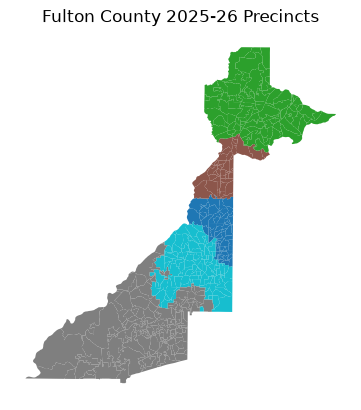

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas

def fulton_city(precinct: str):
    city_codes = {
        'CH': 'Chattahoochee Hills',
        'PA': 'Palmetto',
        'SC': 'South Fulton',
        'UC': 'Union City',
        'CP': 'College Park',
        'EP': 'East Point',
        'HP': 'Hapeville',
        'FA': 'Fairburn',
        'SS': 'Sandy Springs',
        'RW': 'Roswell',
        'JC': 'Johns Creek',
        'AP': 'Alpharetta',
        'ML': 'Milton',
        'MP': 'Mountain Park'
    }

    f2 = precinct[:2]
    try:
        city = city_codes[f2]
    except KeyError:
        city = 'Atlanta'

    return city

def atl_subregions(precinct_bloc: str):
    return {
        '01': 'South/West Atlanta',
        '02': 'Buckhead-Midtown',
        '03': 'South/West Atlanta',
        '04': 'South/West Atlanta',
        '05': 'Buckhead-Midtown',
        '06': 'Buckhead-Midtown',
        '07': 'Buckhead-Midtown',
        '08': 'Buckhead-Midtown',
        '09': 'South/West Atlanta',
        '10': 'South/West Atlanta',
        '11': 'South/West Atlanta',
        '12': 'South/West Atlanta'
    }[precinct_bloc]

def fulton_subregion(city):
    city_map = {
        'Roswell': 'North Fulton',
        'Milton': 'North Fulton',
        'Alpharetta': 'North Fulton',
        'Johns Creek': 'North Fulton',
        'Mountain Park': 'North Fulton',
        'Sandy Springs': 'Sandy Springs',
        'Atlanta': 'Atlanta', # We will split ATL later
        'South Fulton': 'South Fulton',
        'Chattahoochee Hills': 'South Fulton',
        'Palmetto': 'South Fulton',
        'Fairburn': 'South Fulton',
        'Union City': 'South Fulton',
        'College Park': 'South Fulton',
        'East Point': 'South Fulton',
        'Hapeville': 'South Fulton'
    }

    return city_map[city]

fulton2025 = geopandas.read_file('./gis/Fulton2025.zip')
fulton2025 = fulton2025.rename(columns={'VoterDist': 'Precinct', 'OBJECTID': 'Precinct ID'})
fulton2025 = fulton2025.set_index('Precinct', drop=False)
fulton2025['County'] = 'Fulton'
fulton2025['Election'] = '2026'
fulton2025['City'] = fulton2025['Precinct'].apply(fulton_city)
fulton2025.loc['FC02', 'City'] = 'South Fulton' # Technically unincorporated
fulton2025['Subregion'] = fulton2025['City'].apply(fulton_subregion)
fulton2025.loc[fulton2025['City'] == 'Atlanta', 'Subregion'] = fulton2025.loc[fulton2025['City'] == 'Atlanta', 'Precinct'].map(lambda x: atl_subregions(x[:2]))

ax = fulton2025.plot(column='Subregion')
ax.set_title('Fulton County 2025-26 Precincts')
ax.set_axis_off()
plt.show()

# Cobb County

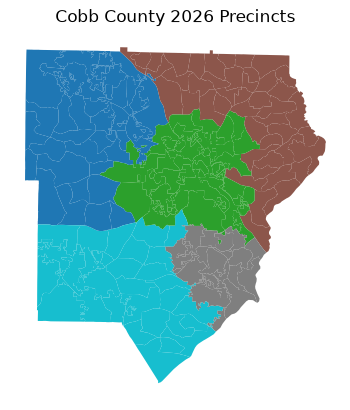

In [63]:
import matplotlib.pyplot as plt
import geopandas

def cobb_city(precinct_group: str):
    cities = [
        'Acworth', 'Austell', 'Kennesaw', 'Mableton',
        'Marietta', 'Powder Springs', 'Smyrna'
    ]

    return precinct_group if precinct_group.title() in cities else 'Unincorporated Cobb' 

def cobb_subregion(precinct_group: str):
    try:
        cobb1 = 'Kennesaw-Acworth'
        cobb2 = 'Marietta'
        cobb3 = 'South Cobb'
        cobb4 = 'Smyrna-Vinings'
        return {
            # Kennesaw-Acworth
            'Acworth': cobb1,
            'Baker': cobb1,
            'Big Shanty': cobb1,
            'Dowell': cobb1,
            'Durham': cobb1,
            'Ford': cobb1,
            'Frey': cobb1,
            'Harrison': cobb1,
            'Hayes': cobb1,
            'Kemp': cobb1,
            'Kennesaw': cobb1,
            'Lost Mountain': cobb1,
            'Mars Hill': cobb1,
            'Mcclure': cobb1,
            'North Cobb': cobb1,
            'Oregon': cobb1,
            'Pine Mountain': cobb1,
            'Vaughan': cobb1,

            # Marietta
            'Cheatham Hill': cobb2,
            'Dobbins': cobb2,
            'East Piedmont': cobb2,
            'Elizabeth': cobb2,
            'Marietta': cobb2,
            'Powers Ferry': cobb2,
            'Sewell Mill': cobb2,
            'Terrell Mill': cobb2,

            # South Cobb
            'Austell': cobb3,
            'Birney': cobb3,
            'Clarkdale': cobb3,
            'Fair Oaks': cobb3,
            'Mableton': cobb3,
            'Macland': cobb3,
            'Mceachern': cobb3,
            'Powder Springs': cobb3,
            'Sweetwater': cobb3,

            # Smyrna-Vinings
            'Smyrna': cobb4,
            'Vinings': cobb4,
            'Norton Park': cobb4,
            'Nickajack': cobb4,
            'Oakdale': cobb4,
        }[precinct_group.title()]

    except KeyError:
        return 'North East Cobb'

cobb2026 = geopandas.read_file('./gis/Cobb2026.zip')
cobb2026 = cobb2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
cobb2026 = cobb2026.set_index('Precinct', drop=False)
cobb2026['County'] = 'Cobb'
cobb2026['Election'] = '2026'
cobb2026['Precinct Group'] = cobb2026['Precinct'].map(lambda x: ' '.join(x.split(' ')[:-1]))
cobb2026['City'] = cobb2026['Precinct Group'].apply(cobb_city)
cobb2026['Subregion'] = cobb2026['Precinct Group'].apply(cobb_subregion)
cobb2026.loc['OREGON 03', 'Subregion'] = 'Marietta'
cobb2026.loc[['OREGON 02', 'OREGON 04'], 'Subregion'] = 'South Cobb'
cobb2026.loc[['BIG SHANTY 02'], 'Subregion'] = 'North East Cobb'

ax = cobb2026.plot(column='Subregion')
ax.set_title('Cobb County 2026 Precincts')
ax.set_axis_off()
plt.show()

# Cherokee County

Cherokee County saw no changes in precincts between 2022 and 2026. Each precinct will constitute a separate reporting group.

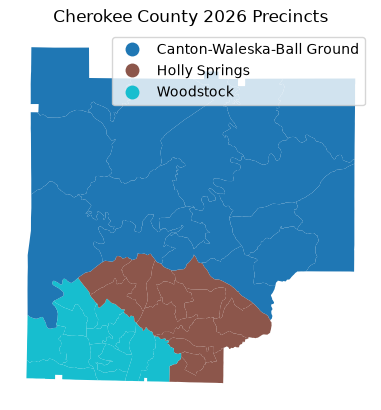

In [64]:
import matplotlib.pyplot as plt
import geopandas

def cherokee_subregion(precinct: str):
    try:
        cherokee1 = 'Woodstock'
        cherokee2 = 'Canton-Waleska-Ball Ground'
        return {
            # Woodstock
            'Clark Creek': cherokee1,
            'Oak Grove': cherokee1,
            'Bells': cherokee1,
            'Victoria': cherokee1,
            'Bascomb': cherokee1,
            'Hillside': cherokee1,
            'Rosecreek': cherokee1,
            'Carmel': cherokee1,
            'Dixie': cherokee1,
            'Booth': cherokee1,
            'Deer Run': cherokee1,
            'Woodstock': cherokee1,
            'Lickskillet': cherokee1,

            # Canton-Waleska-Ball Ground
            'Canton': cherokee2,
            'Waleska': cherokee2,
            'Ball Ground': cherokee2,
            'Sutallee': cherokee2,
            'River Green': cherokee2,
            'Hickory Log': cherokee2,
            'Univeter': cherokee2,
            'Avery': cherokee2,
            'Union Hill': cherokee2,
            'Macedonia': cherokee2,
            'Free Home': cherokee2,
            'Hightower': cherokee2,
            'Conns Creek': cherokee2,
            'Airport': cherokee2,
            'R M Moore': cherokee2,
            'Salacoa': cherokee2,
        }[precinct.title()]

    except KeyError:
        return 'Holly Springs'

cherokee2026 = geopandas.read_file('./gis/Cherokee2026.zip')
cherokee2026 = cherokee2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
cherokee2026 = cherokee2026.set_index('Precinct', drop=False)
cherokee2026['County'] = 'Cherokee'
cherokee2026['Election'] = '2026'
cherokee2026['Subregion'] = cherokee2026['Precinct'].apply(cherokee_subregion)
cherokee2026['Reporting Group'] = cherokee2026['Precinct']

ax = cherokee2026.plot(column='Subregion', legend=True)
ax.set_title('Cherokee County 2026 Precincts')
ax.set_axis_off()
plt.show()

# Forsyth County

Forsyth County has dramatically altered it's precincts since 2022. Almost the whole North Forsyth Subregion has seen interlocking boundary changes, meaning it has to be grouped into one giant reporting group.

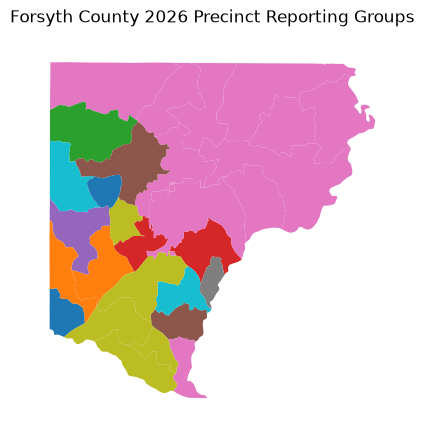

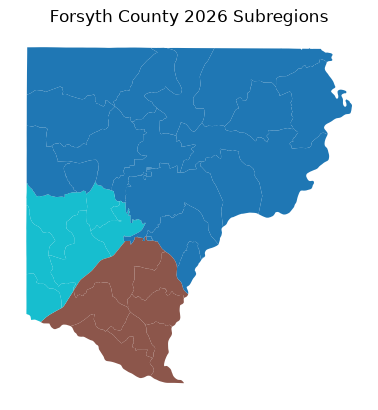

In [65]:
import matplotlib.pyplot as plt
import geopandas

def forsyth_subregion(precinct: str):
    try:
        forsyth1 = 'South Forsyth'
        forsyth2 = 'West Forsyth'
        return {
            # South Forsyth
            'Big Creek': forsyth1,
            'Daves Creek': forsyth1,
            'Johns Creek': forsyth1,
            'Mathis': forsyth1,
            'Nichols': forsyth1,
            'Old Atlanta': forsyth1,
            'Windermere': forsyth1,

            # West Forsyth
            'Midway': forsyth2,
            'Fowler': forsyth2,
            'Brandywine': forsyth2,
            'Grassland': forsyth2,
            'Sawmill Branch': forsyth2,
            'Lakeland': forsyth2,
        }[precinct]

    except KeyError:
        return 'Cumming-North Forsyth'

forsyth2026 = geopandas.read_file('./gis/Forsyth2026.zip')
forsyth2026 = forsyth2026.rename(columns={'name': 'Precinct', 'OBJECTID': 'Precinct ID'})
forsyth2026 = forsyth2026.set_index('Precinct', drop=False)
forsyth2026['County'] = 'Forsyth'
forsyth2026['Election'] = '2026'
forsyth2026['Subregion'] = forsyth2026['Precinct'].apply(forsyth_subregion)

# Precinct reporting groups
forsyth2026['Reporting Group'] = forsyth2026['Precinct']
forsyth2026.loc[['Johns Creek', 'Mathis', 'Big Creek', 'Daves Creek'], 'Reporting Group'] = 'South Forsyth Precinct Reporting Group 1'
forsyth2026.loc[['Otwell', 'Coal Mountain', 'Matt', 'Hightower', 'Crossroads', 'Keith Bridge', 'Chestatee', 
                 'Browns Bridge', 'Cumming', 'Lanier'], 'Reporting Group'] = 'North Forsyth Precinct Reporting Group 1'

ax = forsyth2026.plot(column='Reporting Group')
ax.set_title('Forsyth County 2026 Precinct Reporting Groups')
ax.set_axis_off()

ax2 = forsyth2026.plot(column='Subregion')
ax2.set_title('Forsyth County 2026 Subregions')
ax2.set_axis_off()
plt.show()

# Hall County

Hall County saw no changes in precincts between 2022 and 2026. Each precinct will constitute a separate reporting group.

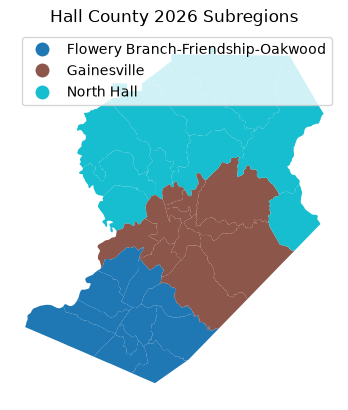

In [66]:
import matplotlib.pyplot as plt
import geopandas

def hall_precinct_group(precinct: str):
    precinct_name_only = precinct.split('-')[1]
    nmwds = precinct_name_only.split(' ')
    nmwds = [word for word in nmwds if word not in ['I', 'II', 'III', 'IV', 'V']]
    return ' '.join(nmwds)


def hall_subregion(precinct_group: str):
    try:
        hall1 = 'Flowery Branch-Friendship-Oakwood'
        hall2 = 'Gainesville'
        return {
            # Flowery Branch-Friendship-Oakwood
            'Flowery Branch': hall1,
            'Friendship': hall1,
            'Oakwood': hall1,
            'Roberts': hall1,
            'Morgan': hall1,

            # Gainesville
            'Gainesville': hall2,
            'Wilson': hall2,
            'Chicopee': hall2,
            'Candler': hall2,
            'Tadmore': hall2,
            'Glade': hall2,
        }[precinct_group]

    except KeyError:
        return 'North Hall'

hall2026 = geopandas.read_file('./gis/Hall2026.geojson')
hall2026 = hall2026.rename(columns={'NAME': 'Precinct', 'OBJECTID': 'Precinct ID'})
hall2026 = hall2026.set_index('Precinct', drop=False)
hall2026['County'] = 'Hall'
hall2026['Election'] = '2026'
hall2026['Precinct Group'] = hall2026['Precinct'].apply(hall_precinct_group)
hall2026['Subregion'] = hall2026['Precinct Group'].apply(hall_subregion)
hall2026['Reporting Group'] = hall2026['Precinct']

ax = hall2026.plot(column='Subregion', legend=True)
ax.set_title('Hall County 2026 Subregions')
ax.set_axis_off()
plt.show()

# Newton County

Like in Forsyth, there have been substantial precinct boundary changes from 2022.

## 2020 Census - Population by Subregion

* South Newton: 38,866 (60.5% White; Trump +17.2)
* Covington: 74,117 (59.2% Black; Harris +34.6)

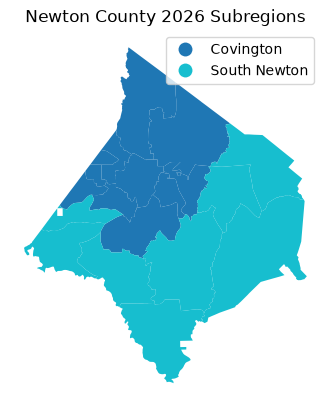

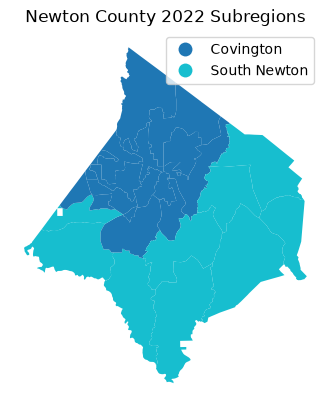

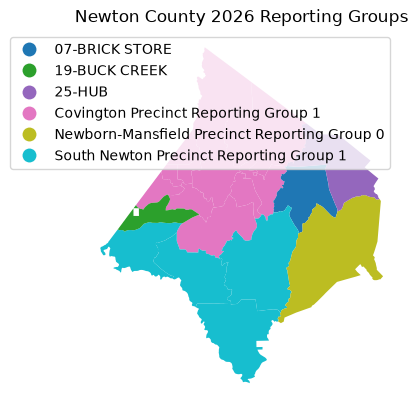

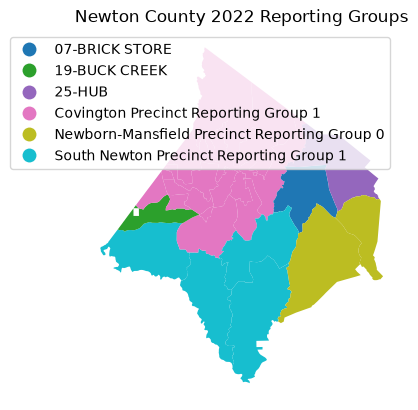

In [67]:
import matplotlib.pyplot as plt
import geopandas


def newton_subregion(precinct_group: str):
    try:
        newton1 = 'South Newton'
        return {
            '07-BRICK STORE': newton1,
            '25-HUB': newton1,
            'Newborn-Mansfield Precinct Reporting Group 0': newton1,
            'South Newton Precinct Reporting Group 1': newton1,
            '19-BUCK CREEK': newton1
        }[precinct_group]

    except KeyError:
        return 'Covington'

newton2026 = geopandas.read_file('./gis/Newton2026.zip')
newton2026 = newton2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
newton2026 = newton2026.set_index('Precinct', drop=False)
newton2026['County'] = 'Newton'
newton2026['Election'] = '2026'

newton2022 = geopandas.read_file('./gis/Newton2022.zip')
newton2022 = newton2022.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
newton2022 = newton2022.set_index('Precinct', drop=False)

# Reporting groups
newton2026['Reporting Group'] = newton2026['Precinct']
south_newton_prg_precincts = ['10-DOWNS', '18-ROCKY PLAINS', '06-BREWERS', '14-LEGUINN']
newton2026.loc[south_newton_prg_precincts, 'Reporting Group'] = 'South Newton Precinct Reporting Group 1'
newton2026.loc[['15-MANSFIELD'], 'Reporting Group'] = 'Newborn-Mansfield Precinct Reporting Group 0'
covington_prg_precincts = ['17-OXFORD', '12-GUM CREEK', '20-STANSELLS', '04-ALCOVY', '05-COVINGTON MILLS', 
                           '03-ALMON', '09-LIVINGSTON', '23-FAIRVIEW', '13-BEAVERDAM', '02-TOWN', '24-CROWELL']
newton2026.loc[covington_prg_precincts, 'Reporting Group'] = 'Covington Precinct Reporting Group 1'

newton2022['Reporting Group'] = newton2022['Precinct']
newton2022.loc[['15-MANSFIELD', '16-NEWBORN'], 'Reporting Group'] = 'Newborn-Mansfield Precinct Reporting Group 0'
newton2022.loc[covington_prg_precincts + ['01-CITY POND', '08-CEDAR SHOALS'], 'Reporting Group'] = 'Covington Precinct Reporting Group 1'
newton2022.loc[south_newton_prg_precincts, 'Reporting Group'] = 'South Newton Precinct Reporting Group 1'

# Subregions
newton2026['Subregion'] = newton2026['Reporting Group'].apply(newton_subregion)
newton2022['Subregion'] = newton2022['Reporting Group'].apply(newton_subregion)

ax = newton2026.plot(column='Subregion', legend=True)
ax.set_title('Newton County 2026 Subregions')
ax.set_axis_off()

ax1 = newton2022.plot(column='Subregion', legend=True)
ax1.set_title('Newton County 2022 Subregions')
ax1.set_axis_off()

ax2 = newton2026.plot(column='Reporting Group', legend=True)
ax2.set_title('Newton County 2026 Reporting Groups')
ax2.set_axis_off()

ax3 = newton2022.plot(column='Reporting Group', legend=True)
ax3.set_title('Newton County 2022 Reporting Groups')
ax3.set_axis_off()
plt.show()

# Rockdale County

Rockdale County is currently grouped into 1 countywide subregion.

Four precincts were merged into two between 2022 and 2026 and thus are included in reporting groups. No changes were made between 2018 and 2022. 

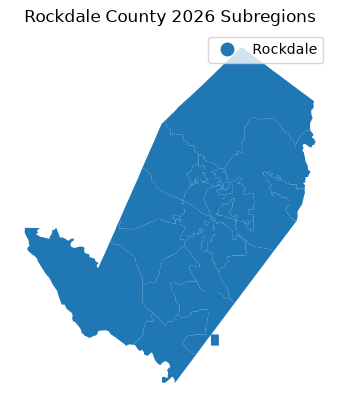

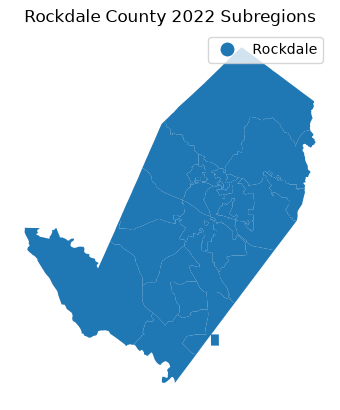

In [68]:
import matplotlib.pyplot as plt
import geopandas


rockdale2026 = geopandas.read_file('./gis/Rockdale2026.zip')
rockdale2026 = rockdale2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
rockdale2026 = rockdale2026.set_index('Precinct', drop=False)
rockdale2026['County'] = 'Rockdale'
rockdale2026['Election'] = '2026'

rockdale2022 = geopandas.read_file('./gis/Rockdale2022.zip')
rockdale2022 = rockdale2022.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
rockdale2022 = rockdale2022.set_index('Precinct', drop=False)
rockdale2022['County'] = 'Rockdale'
rockdale2022['Election'] = '2022'

# Reporting groups
rockdale2026['Reporting Group'] = rockdale2026['Precinct']
rockdale2026.loc['MI', 'Reporting Group'] = 'HI-MI Precinct Reporting Group 0'
rockdale2026.loc['MA', 'Reporting Group'] = 'HC-MA Precinct Reporting Group 0'

rockdale2022['Reporting Group'] = rockdale2022['Precinct']
rockdale2022.loc[['MI', 'HI'], 'Reporting Group'] = 'HI-MI Precinct Reporting Group 0'
rockdale2022.loc[['MA', 'HC'], 'Reporting Group'] = 'HC-MA Precinct Reporting Group 0'

# Subregions
rockdale2026['Subregion'] = 'Rockdale'
rockdale2022['Subregion'] = 'Rockdale'

ax = rockdale2026.plot(column='Subregion', legend=True)
ax.set_title('Rockdale County 2026 Subregions')
ax.set_axis_off()

ax1 = rockdale2022.plot(column='Subregion', legend=True)
ax1.set_title('Rockdale County 2022 Subregions')
ax1.set_axis_off()
plt.show()

# Henry County

There appear to have been no precinct changes between 2018 and 2026.

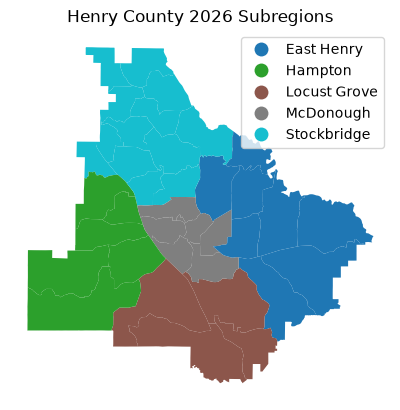

In [69]:
import matplotlib.pyplot as plt
import geopandas

henry2026 = geopandas.read_file('./gis/Henry2026.zip')
henry2026 = henry2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
henry2026 = henry2026.set_index('Precinct', drop=False)
henry2026['County'] = 'Henry'
henry2026['Election'] = '2026'
henry2026['Reporting Group'] = henry2026['Precinct']

henry2026['Subregion'] = 'Stockbridge'
henry2026.loc[['NORTH HAMPTON', 'SOUTH HAMPTON', 'PATES CREEK', 
               'DUTCHTOWN', 'MOUNT CARMEL', 'OAKLAND'], 'Subregion'] = 'Hampton'
henry2026.loc[['UNITY GROVE', 'GROVE PARK', 'LOCUST GROVE', 'LOWES'], 'Subregion'] = 'Locust Grove'
henry2026.loc[['LAKE HAVEN', 'WESLEY LAKES', 'MCDONOUGH CENTRAL', 
               'MCDONOUGH', 'SHILOH', 'WESTSIDE'], 'Subregion'] = 'McDonough'
henry2026.loc[['EAST LAKE', 'KELLEYTOWN', 'TIMBERRIDGE', 'LAKE DOW',
               'MCMULLEN', 'MT BETHEL', 'TUSSAHAW', 'SANDY RIDGE'], 'Subregion'] = 'East Henry'

ax = henry2026.plot(column='Subregion', legend=True)
ax.set_title('Henry County 2026 Subregions')
ax.set_axis_off()
plt.show()

# Clayton County

Clayton County saw precinct changes at every stage in between the 2018, 2020, 2022, and 2026 elections.

The county is grouped into four subregions:

* Morrow-Forest Park: 90,393 (62.1% Black; Harris +63.8)
* Riverdale: 76,691 (81% Black; Harris +77.6)
* Jonesboro: 87,597 (73.7% Black; Harris +67.2)
* South Clayton: 42,914 (78.3% Black; Harris +72.2)

Demographic data is from 2020 United States census.

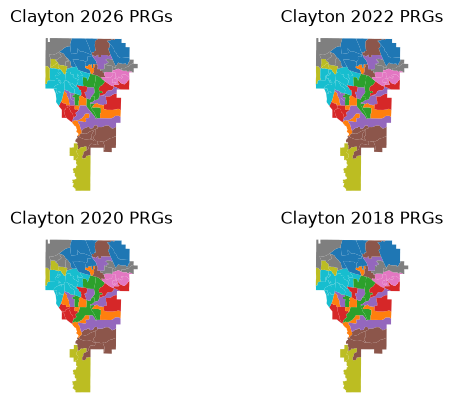

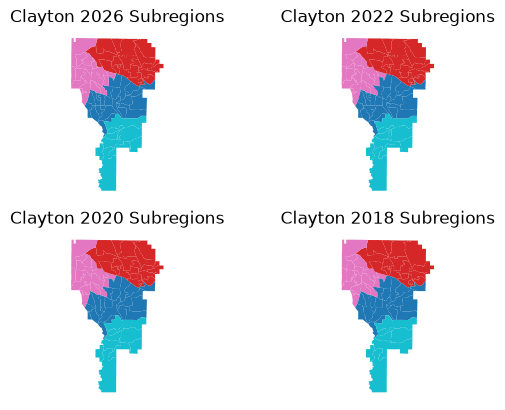

In [70]:
import matplotlib.pyplot as plt
import geopandas

def clayton_rg(precinct: str):
    try:
        return {
            'Oak 3': 'Oak 3 & 5 Precinct Reporting Group 0',
            'Oak 5': 'Oak 3 & 5 Precinct Reporting Group 0',

            'Oak 4': 'Oak 4 & 6 Precinct Reporting Group 0',
            'Oak 6': 'Oak 4 & 6 Precinct Reporting Group 0',

            'Ellenwood': 'Ellenwood Precinct Reporting Group 0',
            'Ellenwood 1': 'Ellenwood Precinct Reporting Group 0',
            'Ellenwood 2': 'Ellenwood Precinct Reporting Group 0',

            'Morrow 5': 'Morrow Precinct Reporting Group 1',
            'Morrow 10': 'Morrow Precinct Reporting Group 1',

            'Morrow 3': 'Morrow Precinct Reporting Group 2',
            'Morrow 11': 'Morrow Precinct Reporting Group 2',

            'Riverdale 1': 'Riverdale Reporting Group 1',
            'Riverdale 3': 'Riverdale Reporting Group 1',
            'Riverdale 8': 'Riverdale Reporting Group 1',
            'Riverdale 12': 'Riverdale Reporting Group 1',

            'Riverdale 5': 'Riverdale Reporting Group 2',
            'Riverdale 9': 'Riverdale Reporting Group 2',

            'Jonesboro 1': 'Jonesboro Reporting Group 1',
            'Jonesboro 17': 'Jonesboro Reporting Group 1',
            'Jonesboro 19': 'Jonesboro Reporting Group 1',

            'Jonesboro 2': 'Jonesboro Reporting Group 2',
            'Jonesboro 20': 'Jonesboro Reporting Group 2',

            'Jonesboro 11': 'Jonesboro Reporting Group 3',
            'Jonesboro 22': 'Jonesboro Reporting Group 3',

            'Jonesboro 4': 'Jonesboro Reporting Group 4',
            'Jonesboro 21': 'Jonesboro Reporting Group 4',

            'Lovejoy 4': 'Lovejoy Reporting Group 1',
            'Lovejoy 8': 'Lovejoy Reporting Group 1',

            'Lovejoy 3': 'Lovejoy Reporting Group 2',
            'Lovejoy 6': 'Lovejoy Reporting Group 2',
            'Lovejoy 7': 'Lovejoy Reporting Group 2',
        }[precinct.title()]

    except KeyError:
        return precinct

def clayton_pg(precinct: str):
    if precinct in ['LAKE CITY', 'ELLENWOOD']:
        return precinct
    return ' '.join(precinct.split(' ')[:-1])

def clayton_subregion(precinct_group: str):
    clayton1 = 'Morrow-Forest Park'
    clayton2 = 'Riverdale'
    clayton3 = 'Jonesboro',
    clayton4 = 'South Clayton'
    return {
        # Morrow-Forest Park
        'Ellenwood': clayton1,
        'Forest Park': clayton1,
        'Lake City': clayton1,
        'Morrow': clayton1,

        # Riverdale
        'Riverdale': clayton2,
        'Oak': clayton2,

        # Jonesboro
        'Jonesboro': clayton3,

        # South Clayton
        'Lovejoy': clayton4,
        'Panhandle': clayton4,
    }[precinct_group.title()]

def import_clayton(year):
    data = geopandas.read_file(f'./gis/Clayton{year}.zip')
    data = data.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
    assert(isinstance(year, str))
    if year == '2020':
        data.loc[data['Precinct'] == 'OAK5', 'Precinct'] = 'OAK 5'
    data = data.set_index('Precinct', drop=False)
    data['County'] = 'Clayton'
    data['Election'] = year
    data['Reporting Group'] = data['Precinct'].apply(clayton_rg)
    data['Precinct Group'] = data['Precinct'].apply(clayton_pg)
    data['Subregion'] = data['Precinct Group'].apply(clayton_subregion)
    return data

[clayton2026, clayton2022, clayton2020, clayton2018] = [import_clayton(year) for year in ['2026', '2022', '2020', '2018']]

clayton_d = [clayton2026, clayton2022, clayton2020, clayton2018]

fig, axes = plt.subplots(2, 2, squeeze=True)
axis_indexes = [[0, 0], [0, 1], [1, 0], [1, 1]]
for [x,y], d in zip(axis_indexes, clayton_d):
    ax = axes[x][y]
    year = d['Election'].tolist()[0]
    d.plot(ax=ax, column='Reporting Group')
    ax.set_title(f'Clayton {year} PRGs')
    ax.set_axis_off()
plt.show()

fig, axes = plt.subplots(2, 2, squeeze=True)
axis_indexes = [[0, 0], [0, 1], [1, 0], [1, 1]]
for [x,y], d in zip(axis_indexes, clayton_d):
    ax = axes[x][y]
    year = d['Election'].tolist()[0]
    d.plot(ax=ax, column='Subregion')
    ax.set_title(f'Clayton {year} Subregions')
    ax.set_axis_off()
plt.show()

# Fayette County

Only boundary change is a small merger in 2026. 

Two subregions:

* Fayetteville: 51,325 (46.8% Black; 39.1% White; Harris: +28.8)
* Peachtree City: 67,869 (70.9% White; Trump +25.8)

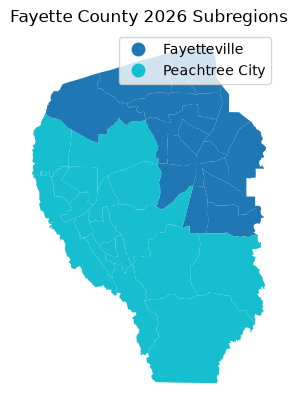

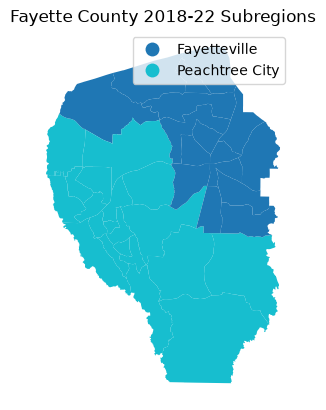

In [71]:
import matplotlib.pyplot as plt
import geopandas


def fayette_subregion(precinct: str):
    try:
        fayette1 = 'Fayetteville'
        return {
            'Antioch': fayette1,
            'Banks': fayette1,
            'Blackrock': fayette1,
            'Europe': fayette1,
            'Fayetteville East': fayette1,
            'Fayetteville West': fayette1,
            'Flint': fayette1,
            'Harps Crossing': fayette1,
            'Hopeful': fayette1,
            'Jeff Davis': fayette1,
            'Kenwood': fayette1,
            'Morning Creek': fayette1,
            'Murphy': fayette1,
            'Oak Ridge': fayette1,
            'Sandy Creek': fayette1,
            'Spring Hill': fayette1,
        }[precinct.title()]
    except KeyError:
        return 'Peachtree City'


fayette2026 = geopandas.read_file('./gis/Fayette2022.zip')
fayette2026 = fayette2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
fayette2026 = fayette2026.set_index('Precinct', drop=False)
fayette2026['County'] = 'Fayette'
fayette2026['Election'] = '2026'
fayette2026['Reporting Group'] = fayette2026['Precinct']
fayette2026.loc[['WINDGATE', 'CAMP CREEK'], 'Reporting Group'] = 'Windgate Precinct Reporting Group'

fayette2026['Subregion'] = fayette2026['Precinct'].apply(fayette_subregion)

fayette2022 = fayette2026.copy()
fayette2022['Election'] = '2022'

fayette2026['PrecinctMg'] = fayette2026['Reporting Group']
fayette2026 = fayette2026.dissolve(by='PrecinctMg')

ax = fayette2026.plot(column='Subregion', legend=True)
ax.set_title('Fayette County 2026 Subregions')
ax.set_axis_off()

ax1 = fayette2022.plot(column='Subregion', legend=True)
ax1.set_title('Fayette County 2018-22 Subregions')
ax1.set_axis_off()
plt.show()

# DeKalb County

Numerous boundary changes between 2018 and 2026, although most do not appear to be substantive. 

Subregions:

* Dunwoody-Brookhaven-Chamblee-Doraville: 152,575 (45.7% White; 26.0% Hispanic; Harris +27)
* Tucker: 88,688 (48.3% White; 23.4% Black; Harris +45)
* Stone Mountain-Scottsdale-Clarkston: 185,629 (73.8% Black; Harris +72.8)
* Lithonia-Stonecrest: 124,817 (94.0% Black; Harris +86.6)
* Panthersville: 94,787 (87.6% Black; Harris +87.2)
* Decatur-Druid Hills: 117,886 (59.6% White; 24.4% Black; Harris +74)


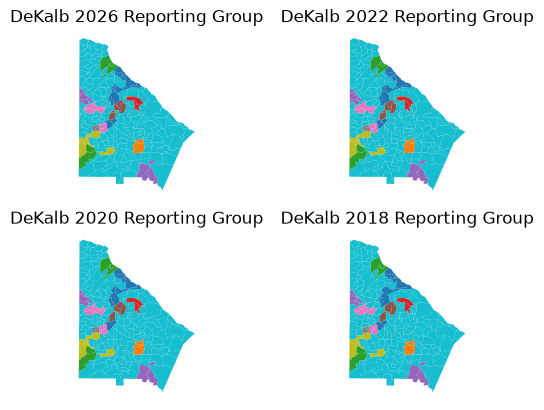

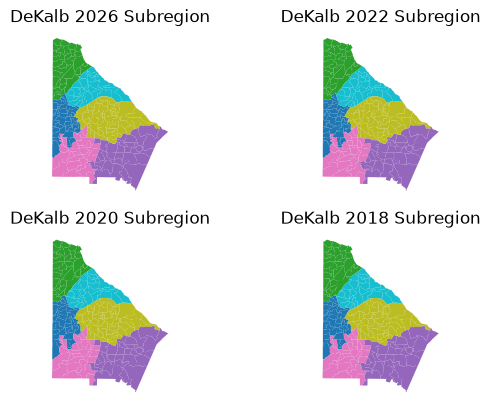

In [72]:
import matplotlib.pyplot as plt
import geopandas

def dekalb_rg(precinct: str):
    try:
        return {
            'Pleasantdale Road': 'DeKalb Precinct Reporting Group 1',
            'Tucker': 'DeKalb Precinct Reporting Group 1', # 2018
            'Tucker Library': 'DeKalb Precinct Reporting Group 1', # 2020-26
            'Livsey Elem': 'DeKalb Precinct Reporting Group 1',
            'Embry Hills': 'DeKalb Precinct Reporting Group 1',
            'Midvale Road': 'DeKalb Precinct Reporting Group 1',
            'Montreal': 'DeKalb Precinct Reporting Group 1',
            'Rehoboth': 'DeKalb Precinct Reporting Group 1',

            'Woodward (Bhavn)': 'DeKalb Precinct Reporting Group 2', # 2018-20
            'Woodward': 'DeKalb Precinct Reporting Group 2', # 2022-26
            'Lavista': 'DeKalb Precinct Reporting Group 2',
            'Harris-Margaret Harris Ed': 'DeKalb Precinct Reporting Group 2',
            'Cross Keys High (Bhavn)': 'DeKalb Precinct Reporting Group 2', # 2018-20
            'Cross Keys High': 'DeKalb Precinct Reporting Group 2', # 2022-26

            'Clarkston Community Center (Cla)': 'DeKalb Precinct Reporting Group 3',
            'Clarkston Community Center': 'DeKalb Precinct Reporting Group 3',
            'Clarkston (Cla)': 'DeKalb Precinct Reporting Group 3',
            'Clarkston': 'DeKalb Precinct Reporting Group 3',
            'Jolly Elem': 'DeKalb Precinct Reporting Group 3',
            'Shaw-Robert Shaw Elem': 'DeKalb Precinct Reporting Group 3',

            'Lavista Road': 'DeKalb Precinct Reporting Group 4',
            'Clairmont Road': 'DeKalb Precinct Reporting Group 4',
            'Medlock': 'DeKalb Precinct Reporting Group 4',
            'Emory Road': 'DeKalb Precinct Reporting Group 4',

            'Winnona Park': 'DeKalb Precinct Reporting Group 5',
            'Winnona Park  (Dec)': 'DeKalb Precinct Reporting Group 5', # sic
            'Avondale High': 'DeKalb Precinct Reporting Group 5',

            'Oakhurst': 'DeKalb Precinct Reporting Group 6',
            'Decatur': 'DeKalb Precinct Reporting Group 6',
            'Decatur (Dec)': 'DeKalb Precinct Reporting Group 6',
            'Oakhurst (Dec)': 'DeKalb Precinct Reporting Group 6',
            'Renfroe (Dec)': 'DeKalb Precinct Reporting Group 6',

            'Mcnair High': 'DeKalb Precinct Reporting Group 7',
            'Burgess Elem (Atl)': 'DeKalb Precinct Reporting Group 7',
            'Burgess Elem': 'DeKalb Precinct Reporting Group 7',
            'Piney Grove': 'DeKalb Precinct Reporting Group 7',
            'East Lake': 'DeKalb Precinct Reporting Group 7',
            'East Lake (Atl)': 'DeKalb Precinct Reporting Group 7',

            'Columbia Middle': 'DeKalb Precinct Reporting Group 8',
            'Flat Shoals': 'DeKalb Precinct Reporting Group 8',

            'Johnson Estates (Atl)': 'DeKalb Precinct Reporting Group 9',
            'Johnson Estates': 'DeKalb Precinct Reporting Group 9',
            'Emory South': 'DeKalb Precinct Reporting Group 9',

            'Covington': 'DeKalb Precinct Reporting Group 10',
            'Avondale (Avo)': 'DeKalb Precinct Reporting Group 10',
            'Avondale': 'DeKalb Precinct Reporting Group 10',

            'Panola Way Elem': 'DeKalb Precinct Reporting Group 11',
            'Miller Grove': 'DeKalb Precinct Reporting Group 11',

            'Gresham Road': 'DeKalb Precinct Reporting Group 12',
            'Meadowview': 'DeKalb Precinct Reporting Group 12',

            'Doraville North': 'DeKalb Precinct Reporting Group 13',
            'Doraville North (Dor)': 'DeKalb Precinct Reporting Group 13',
            'Oakcliff Elem': 'DeKalb Precinct Reporting Group 13',

            'Stone Mill Elem': 'DeKalb Precinct Reporting Group 14',
            'Stone Mtn Middle': 'DeKalb Precinct Reporting Group 14',
            'Stn Mtn Middle': 'DeKalb Precinct Reporting Group 14',

            'Flat Rock Elem': 'DeKalb Precinct Reporting Group 15',
            'Salem Middle': 'DeKalb Precinct Reporting Group 15',
        }[precinct.title()]

    except KeyError:
        return 'Ungrouped'

def dekalb_subregion(precinct_rep_group: str):
    mp = {
        'Stone Mountain-Scottsdale-Clarkston': ['Austin Drive'],
        'Dunwoody-Brookhaven-Chamblee-Doraville': 
            ['Dunwoody', 'Georgetown Sq', 'Peachtree Middle', 'Chesnut Elem', 
             'Tilly Mill Road', 'Winters Chapel', 'North Peachtree', 'Kingsley Elem',
             'Mount Vernon East', 'Mount Vernon West', 'Austin', 'Montclair Elem',
             'Montgomery Elem', 'Kittredge Elem', 'Ashford Parkside', 'Cross Keys High',
             'Ashford Dunwoody Rd', 'Silver Lake', 'Ashford Park Elem', 'Skyland', 
             'Briarwood', 'Brookhaven', 'Oakcliff Elem', 'Dresden Elem',
             'Doraville', 'Chamblee', 'Huntley Hills Elem', 'Woodward'],
        'Decatur-Druid Hills': 
            ['Lavista', 'Harris-Margaret Harris Ed', 'Briarcliff', 'Briar Vista Elem',
             'Lavista Road', 'Emory Road', 'Clairmont Road', 'Medlock', 'Scott', 
             'Johnson Estates', 'Emory South', 'Druid Hills High', 'Clairemont East',
             'Clairemont West', 'Glennwood', 'Ponce De Leon', 'Fernbank Elem', 
             'Lin-Mary Lin Elem', 'Epworth', 'Coan Recreation Center', 'Metropolitan',
             'Burgess Elem', 'East Lake', 'Oakhurst', 'Renfroe', 'Decatur', 'Winnona Park',
             'Avondale High', 'Boulevard', 'Candler Park', 'Mcnair'],
        'Tucker': 
            ['Smoke Rise', 'Hugh Howell', 'Brockett Elem', 'Brockett', 'Tucker', 'Midvale Elem',
             'Livsey Elem', 'Evansdale Elem', 'Embry Hills', 'Pleasantdale Road', 'Warren Tech',
             'Henderson Mill', 'Hawthorne Elem', 'Briarlake Elem', 'Lakeside High', 'Oak Grove',
             'Sagamore Hills', 'Coralwood', 'Shamrock', 'Valley Brook', 'Rehoboth', 'Montreal',
             'Midvale Road', 'Northlake'],
        'Lithonia-Stonecrest': 
            ['King-Ml King Jr High', 'Flat Shoals Parkway', 'Chapel Hill Elem', 'Kelley Chapel Road',
             'Wesley Chapel Library', 'Bethune Middle', 'Miller Grove', 'Panola Road',
             'Marbut Elem', 'Redan Road', 'Redan-Trotti Library', 'Lithonia', 'Stoneview Elem', 
             'Rock Chapel', 'Princeton Elem', 'Fairington Elem', 'Woodrow Road', 'Stonecrest Library',
             'Mcwilliams', 'Browns Mill Elem', 'Salem Middle', 'Flat Rock', 'Candler-Murphey Candler Elem',
             'Snapfinger Road'],
        'Panthersville':
            ['Piney Grove', 'Terry Mill', 'Kelley Lake Elem', 'Flat Shoals Library',
             'Clifton', 'Meadowview', 'Bouldercrest', 'Cedar Grove', 'Oak View', 'Gresham',
             'Candler', 'Knollwood', 'Midway', 'Wadsworth', 'Columbia', 'Snapfinger Elem',
             'Canby Lane', 'Rainbow Elem', 'Mathis-Bob Mathis Elem',
             'Toney Elem', 'Flat Shoals Elem', 'Narvie J Harris Elem', 'Flakes Mill', 
             'Harris-Narvie J Harris Elem', 'Flat Shoals'],
    }
    for group, headers in mp.items():
        for header in headers:
            if precinct_rep_group.title().startswith(header):
                return group
    return 'Stone Mountain-Scottsdale-Clarkston'

def import_dekalb(year):
    data = geopandas.read_file(f'./gis/DeKalb{year}.zip')
    data = data.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
    data = data.set_index('Precinct', drop=False)
    data['County'] = 'DeKalb'
    data['Election'] = year
    data['Reporting Group'] = data['Precinct'].apply(dekalb_rg)
    data['Subregion'] = data['Precinct'].apply(dekalb_subregion)
    return data

dekalb_d = [import_dekalb(year) for year in ['2026', '2022', '2020', '2018']]

for column in ['Reporting Group', 'Subregion']:
    fig, axes = plt.subplots(2, 2, squeeze=True)
    axis_indexes = [[0, 0], [0, 1], [1, 0], [1, 1]]
    for [x,y], d in zip(axis_indexes, dekalb_d):
        ax = axes[x][y]
        year = d['Election'].tolist()[0]
        d.plot(ax=ax, column=column)
        ax.set_title(f'DeKalb {year} {column}')
        ax.set_axis_off()
    plt.show()

dekalb2026 = dekalb_d[0]

# Gwinnett County

No applicable precinct boundary changes

* Peachtree Corners-Norcross: 148,597 (41.3% Hispanic; 23.0% Black; 22.7% White; Harris +21.4)
* Duluth-Suwanee-Buford: 222,766 (38.0% White; 22.9% Asian; 20.7% Black; Harris +6.8)
* North East Gwinnett: 140,897 (49.4% White; 25.0% Black; Trump +4)
* South Gwinnett: 147,261 (53.2% Black; 28.1% White; Harris +40.2)
* Central Gwinnett: 297,541 (31.6% Black; 27.4% White; 24.8% Hispanic; Harris +21.6)

Data is VAP from the 2020 US census.

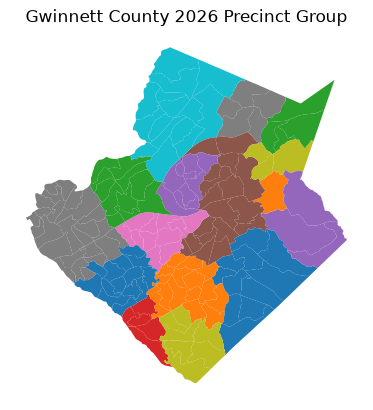

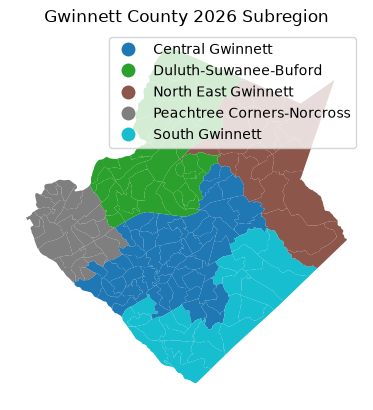

In [73]:
import matplotlib.pyplot as plt
import geopandas

def gwinnett_pg(precinct: str):
    if 'DACULA' in precinct:
        return 'DACULA'
    return ' '.join(precinct.split(' ')[1:-1])

def gwinnett_subregion(precinct_group):
    try:
        gwinnett1 = 'Peachtree Corners-Norcross'
        gwinnett2 = 'Duluth-Suwanee-Buford'
        gwinnett3 = 'North East Gwinnett'
        gwinnett4 = 'South Gwinnett'
        gwinnett5 = 'Central Gwinnett'
        return {
            'Pinckneyville': gwinnett1,
            'Duluth': gwinnett2,
            'Suwanee': gwinnett2,
            'Sugar Hill': gwinnett2,
            'Goodwins': gwinnett2,
            'Hog Mountain': gwinnett3,
            'Pucketts': gwinnett3,
            'Duncans': gwinnett3,
            'Rockycreek': gwinnett3,
            'Dacula': gwinnett3,
            'Harbins': gwinnett3,
            'Baycreek': gwinnett4,
            'Rockbridge': gwinnett4,
            'Garners': gwinnett4,
            'Berkshire': gwinnett5,
            'Cates': gwinnett5,
            'Martins': gwinnett5,
            'Lawrenceville': gwinnett5,
        }[precinct_group.title()]

    except KeyError:
        return precinct_group

gwinnett2026 = geopandas.read_file('./gis/Gwinnett2026.zip')
gwinnett2026 = gwinnett2026.rename(columns={'PRECINCT_N': 'Precinct', 'ID': 'Precinct ID'})
gwinnett2026 = gwinnett2026.set_index('Precinct', drop=False)
gwinnett2026['County'] = 'Gwinnett'
gwinnett2026['Election'] = '2026'
gwinnett2026['Reporting Group'] = gwinnett2026['Precinct']
gwinnett2026['Precinct Group'] = gwinnett2026['Precinct'].apply(gwinnett_pg)
gwinnett2026['Subregion'] = gwinnett2026['Precinct Group'].apply(gwinnett_subregion)

ax = gwinnett2026.plot(column='Precinct Group', legend=False)
ax.set_title('Gwinnett County 2026 Precinct Group')
ax.set_axis_off()

ax1 = gwinnett2026.plot(column='Subregion', legend=True)
ax1.set_title('Gwinnett County 2026 Subregion')
ax1.set_axis_off()
plt.show()

# Writing to file

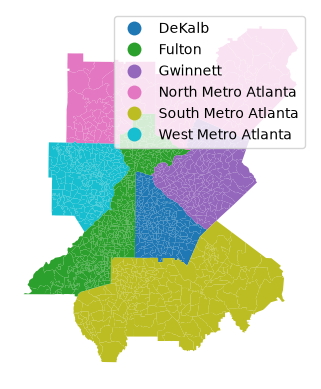

In [ ]:
import pandas as pd

def proj_and_merge(l: list[geopandas.GeoDataFrame]):
    return pd.concat([c.to_crs(crs='WGS 84') for c in l])

counties_by_region = {
    'North Metro Atlanta': ['Cherokee', 'Forsyth', 'Hall'],
    'South Metro Atlanta': ['Fayette', 'Clayton', 'Henry', 'Rockdale', 'Newton'],
    'West Metro Atlanta': ['Cobb', 'Douglas'],
    'Fulton': ['Fulton'],
    'DeKalb': ['DeKalb'],
    'Gwinnett': ['Gwinnett']
}

r2026 = proj_and_merge([cherokee2026, clayton2026, cobb2026, dekalb2026, fayette2026, forsyth2026, fulton2025, gwinnett2026, hall2026, henry2026, newton2026, rockdale2026])
r2026 = r2026[['County', 'Reporting Group', 'geometry', 'Subregion', 'Election']]
r2026['Region'] = 'NA'
for region,counties in counties_by_region.items():
    r2026.loc[r2026['County'].isin(counties), 'Region'] = region 
ax = r2026.plot(column='Region', legend=True)
ax.set_axis_off()

In [ ]:
r2026

,County,Reporting Group,geometry,Subregion,Region
AIR ACRES,Cherokee,AIR ACRES,"POLYGON ((-84.4856 34.11594, -84.48539 34.1161...",Holly Springs,North Metro Atlanta
ARNOLD MILL,Cherokee,ARNOLD MILL,"POLYGON ((-84.43107 34.10415, -84.43122 34.104...",Holly Springs,North Metro Atlanta
AVERY,Cherokee,AVERY,"POLYGON ((-84.36133 34.13702, -84.36177 34.137...",Canton-Waleska-Ball Ground,North Metro Atlanta
BALL GROUND,Cherokee,BALL GROUND,"POLYGON ((-84.39359 34.30172, -84.39349 34.301...",Canton-Waleska-Ball Ground,North Metro Atlanta
BASCOMB,Cherokee,BASCOMB,"POLYGON ((-84.57311 34.15381, -84.57358 34.152...",Woodstock,North Metro Atlanta
...,...,...,...,...,...
BA,Rockdale,BA,"POLYGON ((-84.0445 33.52578, -84.04448 33.5258...",Rockdale,South Metro Atlanta
ST,Rockdale,ST,"POLYGON ((-84.06417 33.57982, -84.06556 33.580...",Rockdale,South Metro Atlanta
SM,Rockdale,SM,"POLYGON ((-84.10433 33.63603, -84.10186 33.640...",Rockdale,South Metro Atlanta
RO,Rockdale,RO,"MULTIPOLYGON (((-84.08396 33.67432, -84.08391 ...",Rockdale,South Metro Atlanta


In [ ]:
r2026.to_json('./regions/regions_metro.json')